# Pediatric Wrist Fracture Detection with YOLOv8

**Author:** Ali Nyirenda

**Dataset:** [GRAZPEDWRI-DX](https://doi.org/10.6084/m9.figshare.14825193) (Nagy et al., 2022, *Scientific Data*). A pediatric wrist trauma X-rays annotated by radiologists. This notebook uses the YOLOv8-formatted subset hosted on Roboflow Universe.

**Goal:** Fine-tune a pretrained YOLOv8 object detector to localize wrist fractures (and related findings) on pediatric trauma X-rays, and evaluate it properly using per-class precision/recall/mAP and a look at failure cases.

**Why this matters clinically:** Wrist fractures are one of the most common pediatric trauma presentations. Automated localization could support faster triage in settings without immediate access to a specialist physician.

**Note on scope:** This is a portfolio/learning project fine-tuning an existing architecture on a public research dataset. This is not a novel model and it has not been clinically validated.


## 1. Setup

In [18]:
# Install necessary libraries for Ultralytics YOLOv8 and Roboflow integration
!pip install -q ultralytics roboflow

### Import Libraries

In [19]:
import os
import glob
import yaml
import random
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd

from ultralytics import YOLO

# This is set to a specific value to ensure that the results are able to be replicated.
random.seed(42)


## 2. Get the data

Two options — Please pick whichever fits your setup.

**Option A — If you've already downloaded the Roboflow zip locally.** Upload it via the Colab file browser (left sidebar), then unzip it:


In [20]:
# OPTION A: if you uploaded grazpedwri-dx.v2i.yolov8.zip to Colab's /content directory

import zipfile # Library to work with ZIP archives

zip_path = "/content/grazpedwri-dx.v2i.yolov8.zip"

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall("/content/dataset")
    print("Extracted to /content/dataset")
else:
    print(f"No zip found at {zip_path}")

Extracted to /content/dataset


**Option B — If you have a Roboflow account this pulls directly from Roboflow with the API and skips manual upload.**

In [21]:
# OPTION B: pull directly via the Roboflow API (uncomment and fill in your key)

# from roboflow import Roboflow
# rf = Roboflow(api_key="YOUR_API_KEY")
# project = rf.workspace("project-bef88").project("grazpedwri-dx")
# dataset = project.version(2).download("yolov8", location="/content/dataset")


In [22]:
DATA_DIR = "/content/dataset"

data_yaml_path = None
for p in glob.glob(f"{DATA_DIR}/**/data.yaml", recursive=True):
    data_yaml_path = p
    break

assert data_yaml_path is not None, "Could not find data.yaml — check your extraction path above"
print("Using data.yaml at:", data_yaml_path)

# Load the data.yaml file to get dataset configuration (class names, paths, etc.)
with open(data_yaml_path) as f:
    data_cfg = yaml.safe_load(f)

print(data_cfg)

Using data.yaml at: /content/dataset/data.yaml
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 8, 'names': ['boneanomaly', 'bonelesion', 'fracture', 'metal', 'periostealreaction', 'pronatorsign', 'softtissue', 'text'], 'roboflow': {'workspace': 'project-bef88', 'project': 'grazpedwri-dx', 'version': 2, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/project-bef88/grazpedwri-dx/dataset/2'}}


In [36]:
import pandas as pd

def get_patient_id(filename):
    # GRAZPEDWRI-DX filenames start with a 4-digit patient number
    # Function to extract patient ID from filename to check for train/test overlap
    return filename.split("_")[0] if "_" in filename else filename[:4]

train_patients = {get_patient_id(f) for f in glob.glob(f"{train_image_dir}/*")}
test_patients = {get_patient_id(f) for f in glob.glob(f"{test_image_dir}/*")}

# Verify that there is no patient overlap between training and test sets
overlap = train_patients & test_patients
print(f"Train patients: {len(train_patients)}, Test patients: {len(test_patients)}")
print(f"Overlapping patients: {len(overlap)} ({len(overlap)/len(test_patients)*100:.1f}% of test set)")

Train patients: 1247, Test patients: 221
Overlapping patients: 0 (0.0% of test set)


## 3. Exploratory Data Analysis

This section checks the dataset directly: how many labeled examples exist per class, and what the actual boxes look like on real radigraphs. Confirming this now avoids training on a mislabeled or lopsided dataset without realizing it.


In [23]:
# Extract class names from the dataset configuration
class_names = data_cfg["names"]
print(f"{len(class_names)} classes: {class_names}")

8 classes: ['boneanomaly', 'bonelesion', 'fracture', 'metal', 'periostealreaction', 'pronatorsign', 'softtissue', 'text']


### What do these classes mean?

- **Fracture** - A discontinuity of the bone with associated soft tissue injury. In this pediatric population, this predominantly means distal radius/ulna fractures (buckle/torus, greenstick, and Salter-Harris physeal injuries being the classic patterns for this age group). The dataset does not specify fracture subtypes; therefore, the model is learning "fracture present," not a classification of specific fracture types.

- **Text** - An annotation artifact (laterality markers, technologist initials, exposure indicators). Included as a negative-signal class so the model learns to disregard radiopaque overlay text rather than falsely identifying it as a clinical finding.

- **Metal** - Metallic objects appear radiopaque (white) on X-ray because the heavy concentration of electrons in metallic atoms completely absorb the X-ray photons, preventing them from reaching the underlying film or digital sensor. This leaves that section unexposed (white), in contrast to tissue that allows the passage of X-ray photons, resulting in exposure (grey, dark). This dataset contains hardware such as K-wires, plates, or incidental metal (jewelry, snap fasteners). These are clinically relevant since post-surgical or previously-treated wrists look different from acute presentations, which affects what "normal" looks like to the model. From the examples reviewed, several appear to be fixation wires (K-wires) rather than plates or incidental jewelry.

- **Periosteal Reaction** - Periosteal new bone formation. In children, the periosteum is loosely attached and reactive, so in the acute pediatric trauma context this finding most often reflects a subacute healing response and can appear within days of injury. That's different from the more sinister differential this finding can raise in isolation: **osteomyelitis** (infection, often with a laminated or "onion-skin" periosteal pattern and possible sequestrum), or a malignant bone tumor such as **Ewing sarcoma** (classically onion-skin or lamellated periosteal reaction) or **osteosarcoma** (classically a sunburst or Codman triangle pattern), though these are far more common at the distal femur/proximal tibia than the wrist. This context matters because the model has no way to distinguish a benign post-traumatic healing reaction from one of these more concerning patterns from imaging alone; it's just detecting that periosteal new bone is present, not classifying why.

- **Pronator Sign** - The pronator quadratus fat pad sign: displacement or obliteration of the normal fat stripe anterior to the distal radius/ulna on the lateral view. Radiologists and clinicians use this sign to help identify occult distal radius fractures. These are cases where the fracture line itself isn't clearly visible, but soft tissue swelling displaces the adjacent fat pad, giving an indirect clue that trauma has occurred.

- **Soft Tissue** - Regional soft tissue swelling, a nonspecific trauma marker. This has a lower specificity than the pronator sign, since swelling can reflect a broader differential such as a sprain, contusion, or hematoma, not fracture specifically but still a relevant secondary cue.

- **Bone Anomaly** - Normal developmental variants (accessory ossification centers, e.g. os styloideum, or other non-pathologic structural variation) rather than acute pathology. Clinically this category exists mainly to prevent the model (and reader) from misinterpreting a variant as an acute finding.

- **Bone Lesion** - Focal intraosseous lesions (most commonly in this age group: unicameral/simple bone cysts, or other benign lytic lesions incidentally captured on trauma imaging), distinct from fracture, and clinically important as an incidental finding that may warrant follow-up regardless of the trauma presentation.

Visual examples of these classes are shown below.

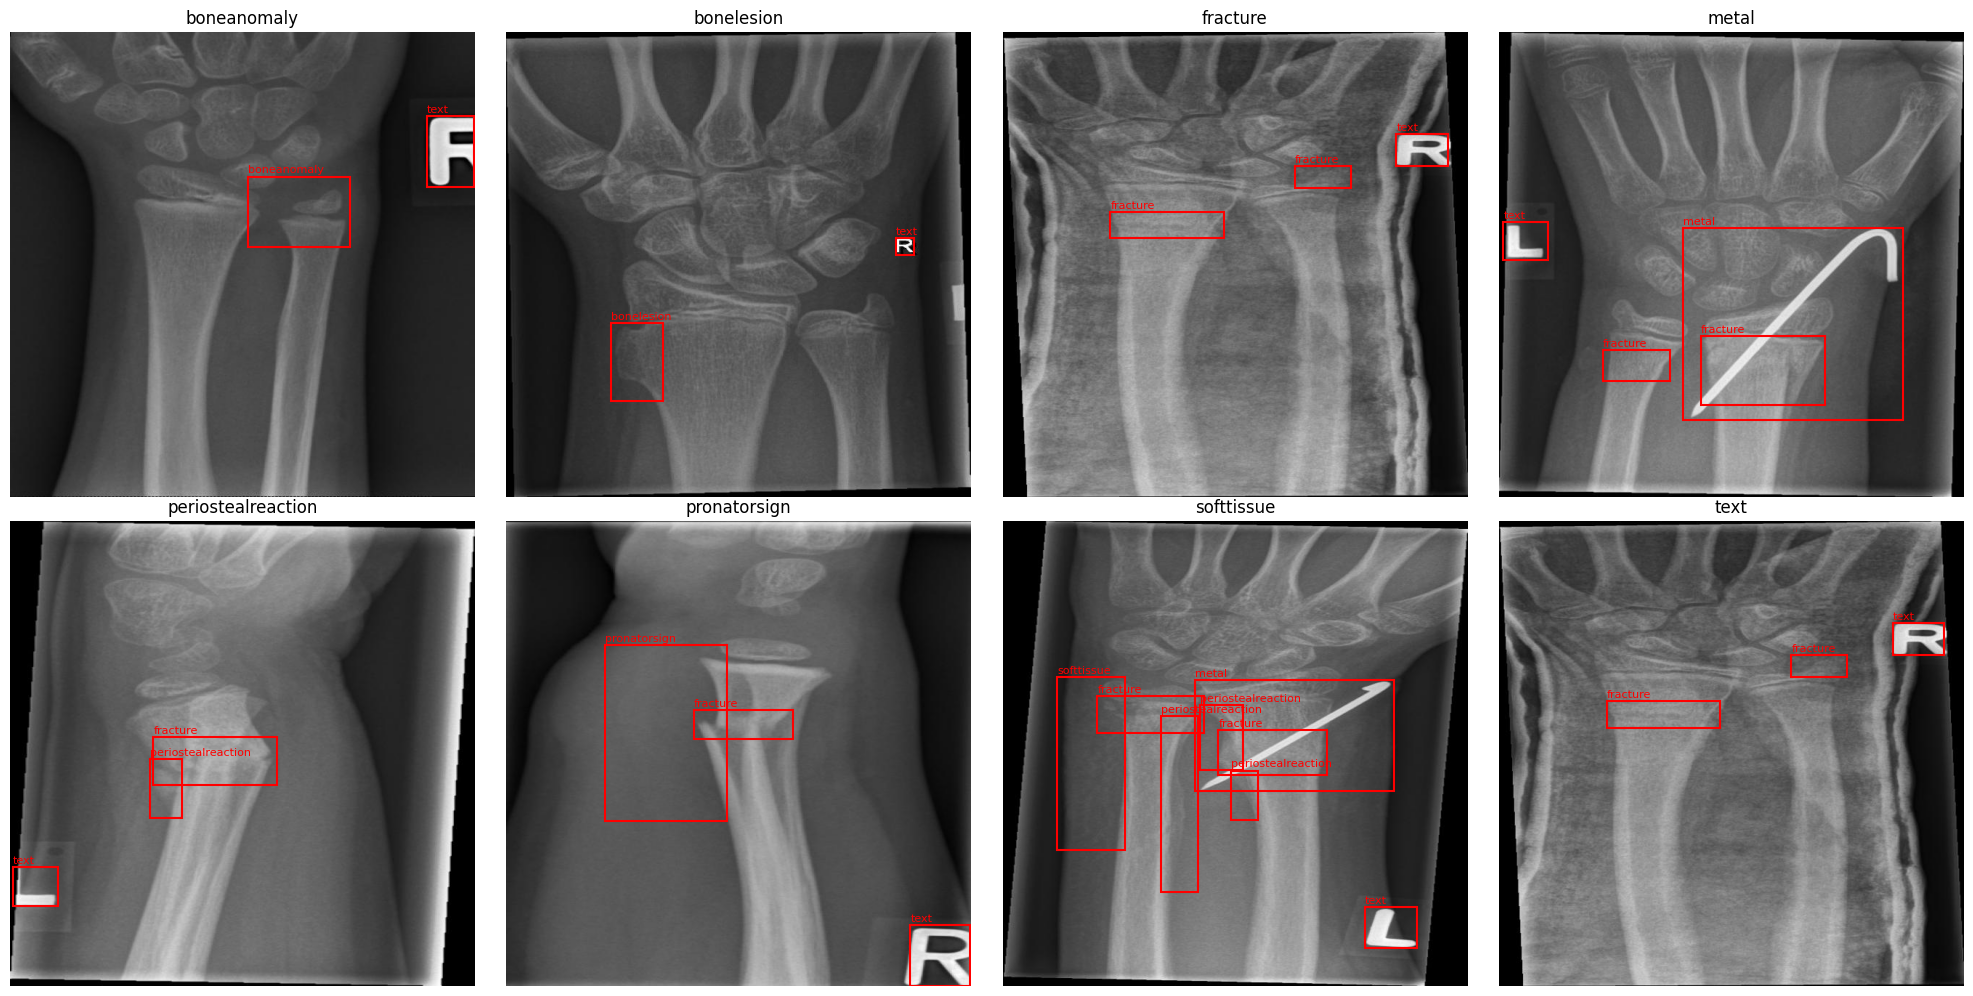

In [24]:
# The following code produces examples for each of the above named classes that
# specifically appear in this dataset.

def find_example_for_class(target_class_name, label_dir, image_dir):
    target_id = class_names.index(target_class_name)
    for label_file in glob.glob(f"{label_dir}/*.txt"):
        boxes = load_yolo_labels(label_file)
        for cls_id, x_c, y_c, w, h in boxes:
            if cls_id == target_id:
                img_path = label_file.replace(label_dir, image_dir).rsplit(".", 1)[0]
                for ext in [".png", ".jpg", ".jpeg"]:
                    if os.path.exists(img_path + ext):
                        return img_path + ext, label_file
    return None, None

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for cls_name, ax in zip(class_names, axes.flatten()):
    img_path, label_path = find_example_for_class(cls_name, train_label_dir, train_image_dir)
    if img_path:
        show_sample(img_path, label_path, ax)
        ax.set_title(cls_name, fontsize=12)
    else:
        ax.axis("off")
plt.tight_layout()
plt.savefig("class_examples.png", dpi=150)
plt.show()

### Number Of Instances Per Class

In [25]:
# The following code outputs the number of instances per class in the training
# set

def yolo_dir_for(split):
    # Handles both flat and nested folder layouts
    for candidate in [f"{DATA_DIR}/{split}/labels", f"{os.path.dirname(data_yaml_path)}/{split}/labels"]:
        if os.path.isdir(candidate):
            return candidate
    return None

train_label_dir = yolo_dir_for("train")
assert train_label_dir is not None, "Could not find train labels folder"
train_image_dir = train_label_dir.replace("labels", "images")

class_counts = {name: 0 for name in class_names}
for label_file in glob.glob(f"{train_label_dir}/*.txt"):
    with open(label_file) as f:
        for line in f:
            cls_id = int(line.split()[0])
            class_counts[class_names[cls_id]] += 1

counts_df = pd.DataFrame(list(class_counts.items()), columns=["class", "count"]).sort_values("count", ascending=False)
counts_df

,class,count
7,text,1947
2,fracture,1455
4,periostealreaction,279
3,metal,68
5,pronatorsign,48
6,softtissue,33
0,boneanomaly,23
1,bonelesion,2


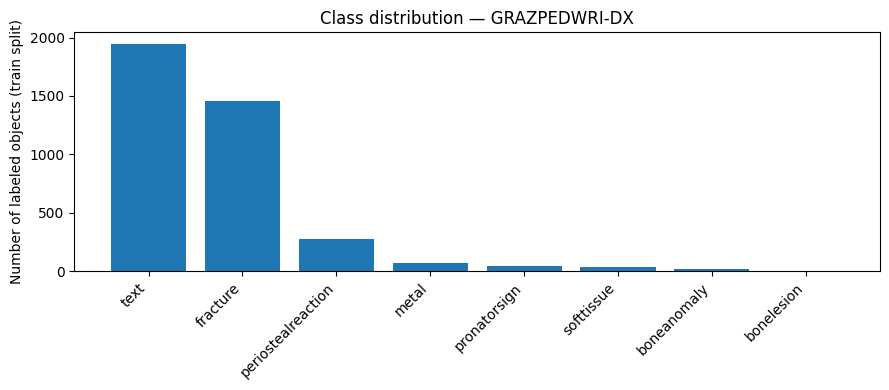

In [26]:
# Visualize the class distribution in the training set
plt.figure(figsize=(9, 4))
plt.bar(counts_df["class"], counts_df["count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of labeled objects (train split)")
plt.title("Class distribution — GRAZPEDWRI-DX")
plt.tight_layout()
plt.show()

Now let's actually look at a few labeled images to confirm the boxes make sense before we train on them.

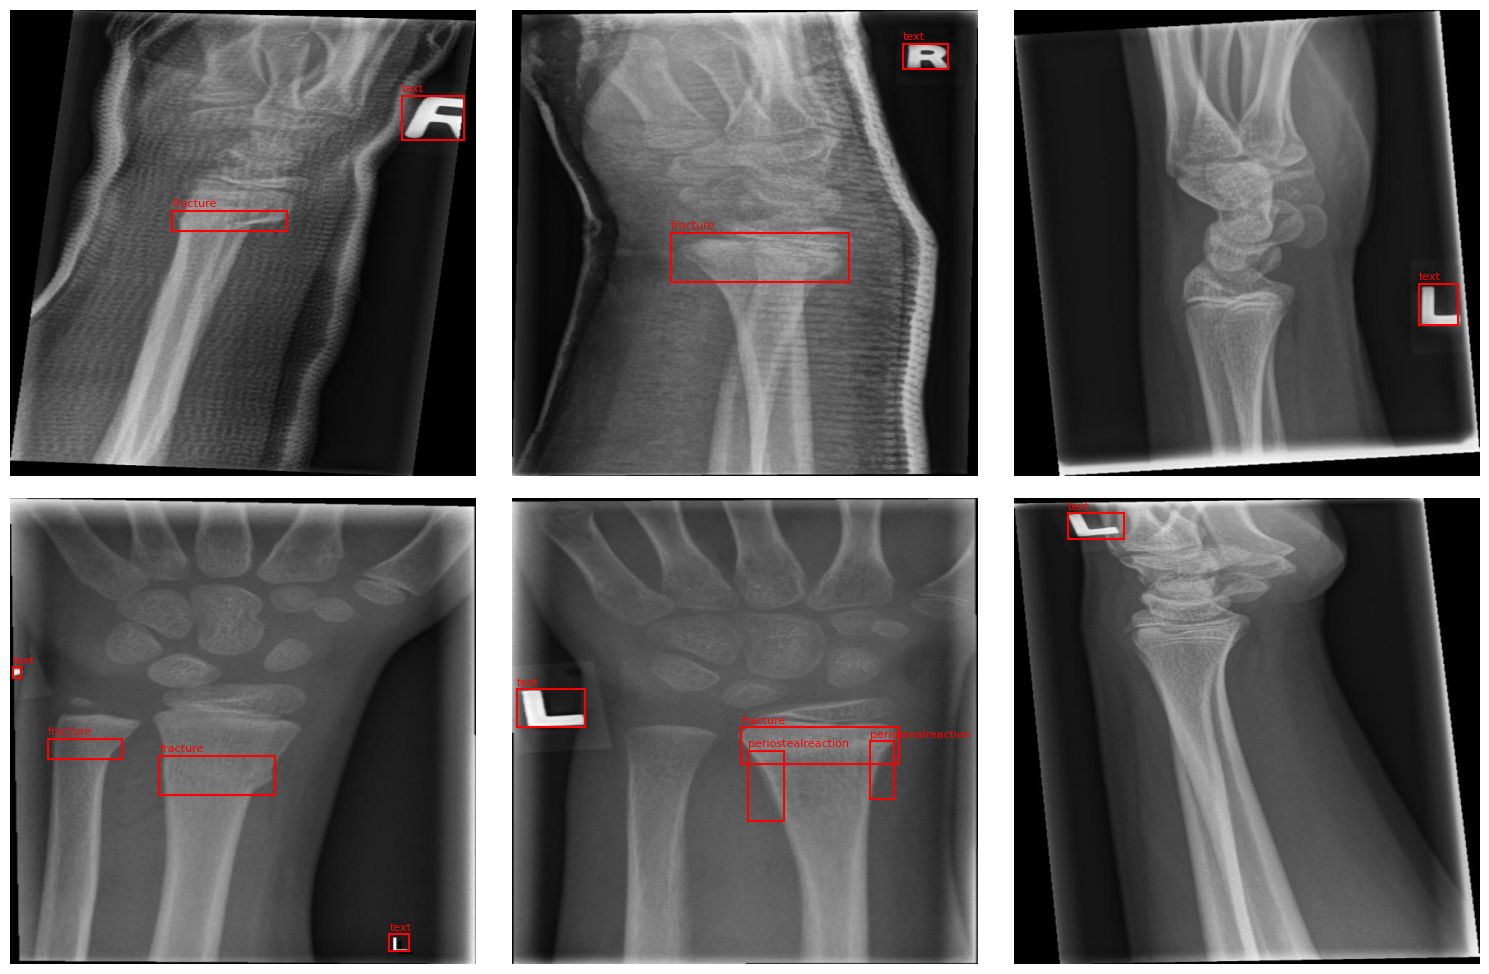

In [27]:
def load_yolo_labels(label_path):
    """Loads YOLO-format bounding box labels from a text file."""
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.split()
            cls_id, x_c, y_c, w, h = int(parts[0]), *map(float, parts[1:5])
            boxes.append((cls_id, x_c, y_c, w, h))
    return boxes

def show_sample(image_path, label_path, ax):
    """Displays an image with its YOLO bounding box annotations."""
    img = plt.imread(image_path)
    h_img, w_img = img.shape[0], img.shape[1]
    ax.imshow(img, cmap="gray")
    for cls_id, x_c, y_c, w, h in load_yolo_labels(label_path):
        x = (x_c - w / 2) * w_img
        y = (y_c - h / 2) * h_img
        rect = patches.Rectangle((x, y), w * w_img, h * h_img,
                                  linewidth=1.5, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        ax.text(x, y - 5, class_names[cls_id], color="red", fontsize=8)
    ax.axis("off")


sample_images = random.sample(glob.glob(f"{train_image_dir}/*"), 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for img_path, ax in zip(sample_images, axes.flatten()):
    label_path = img_path.replace("images", "labels").rsplit(".", 1)[0] + ".txt"
    show_sample(img_path, label_path, ax)
plt.tight_layout()
plt.show()

## 4. Fine-tune YOLOv8

Starting from COCO-pretrained weights (`yolov8n.pt`) rather than training from scratch is known as transfer learning.

### What YOLOv8 is doing here

YOLO ("You Only Look Once") looks at the entire X-ray in a single forward pass through a neural network, directly predicting bounding boxes and class labels at the same time, rather than the older two-stage approach of first proposing regions of interest, then classifying each one separately.

We're not training from scratch: `yolov8n.pt` starts from weights already trained on COCO (a large, general-purpose object dataset), and fine-tuning adapts those existing visual features to wrist X-rays specifically. `n` stands for "nano" — the smallest, fastest YOLOv8 variant, chosen here for training speed over the larger `s`/`m`/`l`/`x` variants.

In [28]:
model = YOLO("yolov8n.pt")  # nano variant — fastest to train, good baseline for a first pass

results = model.train(
    data=data_yaml_path,
    epochs=60,
    imgsz=640,
    batch=16,
    patience=15,       # early stopping if val loss plateaus
    project="wrist_fracture_yolov8",
    name="run1",
    seed=42,
)


Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run1, nbs=64, nms=False, opset=None

## 5. Proper Evaluation

mAP alone hides a lot on a dataset this imbalanced as some classes have 1,000+ examples, others have 20. Breaking results out by class below shows where the model actually works and where it doesn't.


In [32]:
# metrics.box.ap_class_index tells us which classes actually had test instances
# and therefore have a row in p / r / ap50
class_indices = results.box.ap_class_index

per_class_df = pd.DataFrame({
    "class": [results.names[i] for i in class_indices],
    "precision": results.box.p,
    "recall": results.box.r,
    "AP50": results.box.ap50,
})

# Which classes got skipped entirely (no test instances)?
missing_classes = [name for i, name in results.names.items() if i not in class_indices]
if missing_classes:
    print(f"No test instances for: {missing_classes} — these classes have no metrics to report")

per_class_df

,class,precision,recall,AP50
0,boneanomaly,0.000000,0.000000,0.000508
1,bonelesion,0.000000,0.000000,0.000000
2,fracture,0.850280,0.827014,0.880157
3,metal,0.934203,0.875000,0.875000
4,periostealreaction,0.525442,0.464800,0.457413
5,pronatorsign,0.714794,0.300000,0.463886
6,softtissue,0.391511,0.071429,0.154954
7,text,0.972514,0.982456,0.982479


Ultralytics saves a confusion matrix and PR curves automatically under the run folder — worth pulling into the notebook directly:

In [33]:
run_dir = f"wrist_fracture_yolov8/run1"
for fname in ["confusion_matrix.png", "results.png", "PR_curve.png"]:
    path = f"{run_dir}/{fname}"
    if os.path.exists(path):
        img = plt.imread(path)
        plt.figure(figsize=(10, 8))
        plt.imshow(img)
        plt.axis("off")
        plt.title(fname)
        plt.show()


## 6. Visualize predictions

### Why this step matters

Numbers alone (mAP, precision, recall) can hide how a model actually behaves. This section runs the fine-tuned model on unseen test images and draws its predicted boxes directly on them, so we can visually confirm it's finding real fractures, not just scoring well on paper. Included below is at least one lower-confidence or missed detection, along with a note on why it likely happened.


0: 640x640 1 fracture, 1 text, 4.9ms
1: 640x640 1 fracture, 1 text, 4.9ms
2: 640x640 1 fracture, 1 text, 4.9ms
3: 640x640 2 fractures, 3 texts, 4.9ms
4: 640x640 1 fracture, 1 metal, 1 periostealreaction, 1 text, 4.9ms
5: 640x640 1 fracture, 1 text, 4.9ms
6: 640x640 1 text, 4.9ms
7: 640x640 1 text, 4.9ms
Speed: 1.5ms preprocess, 4.9ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)


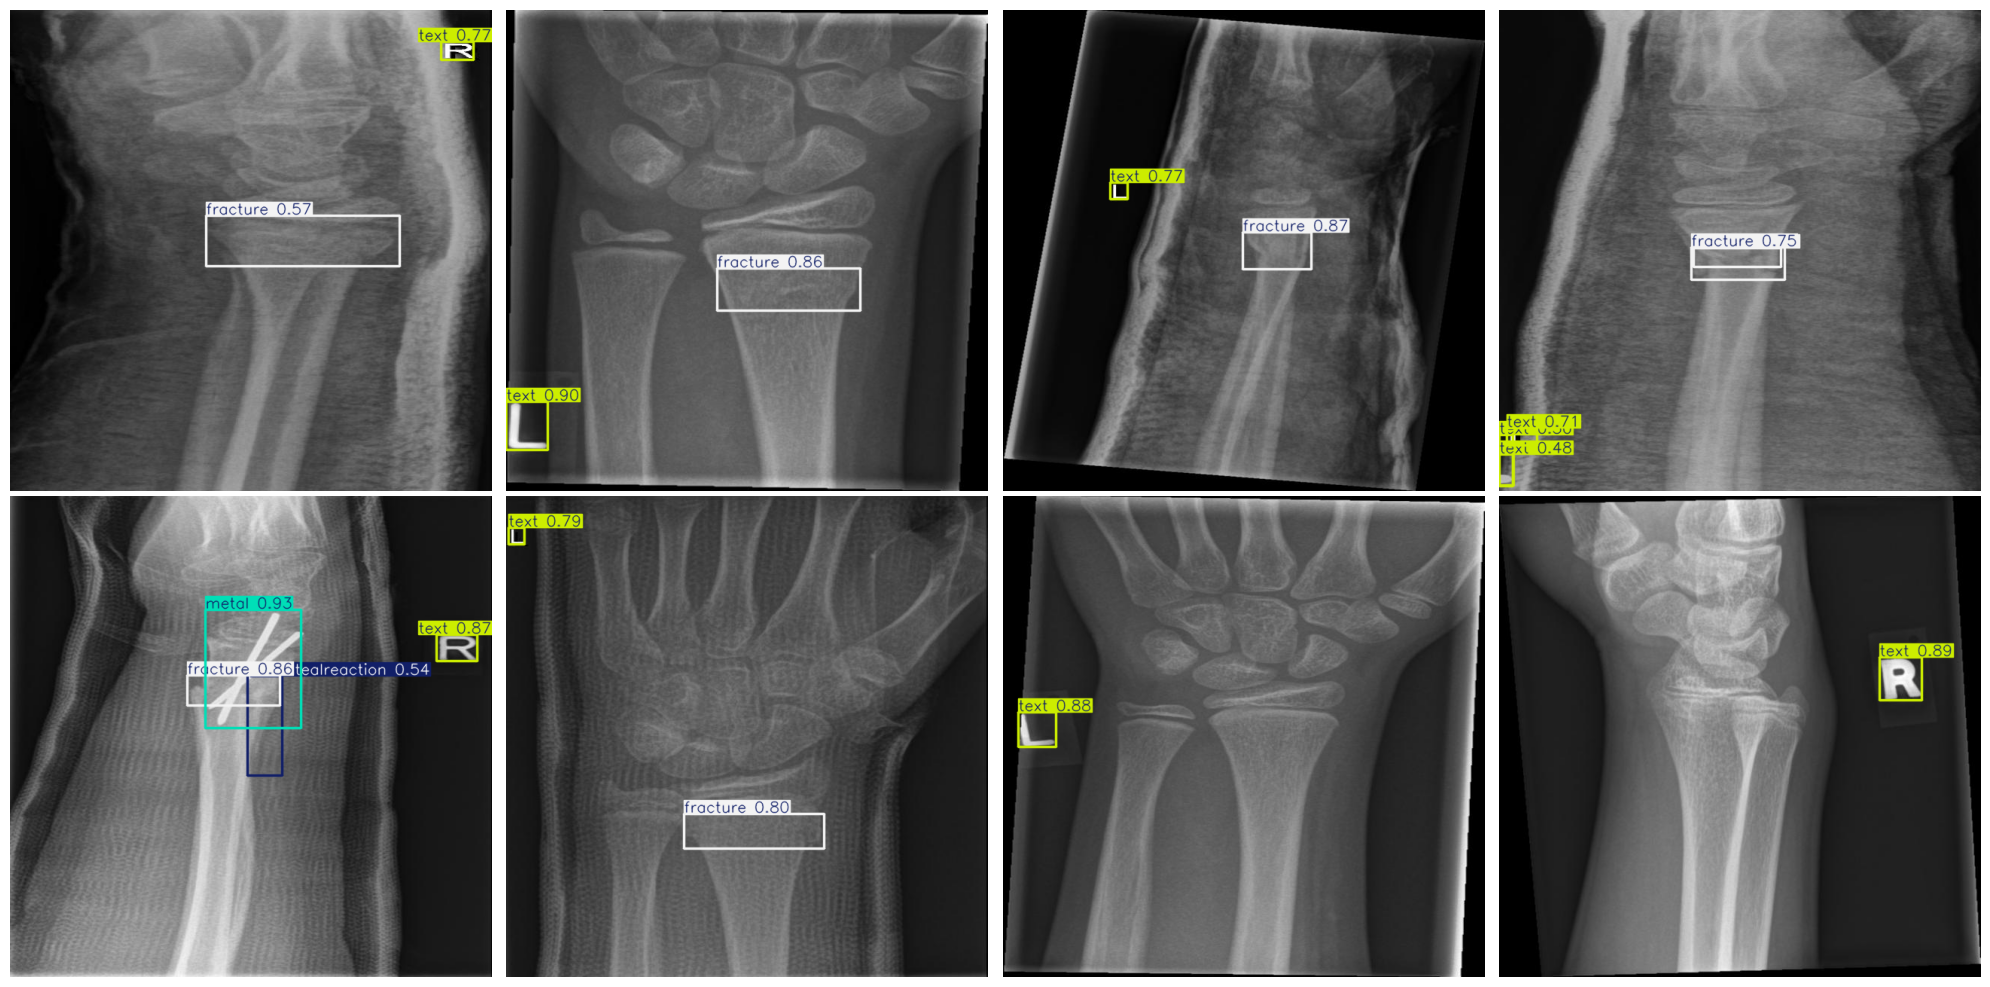

In [34]:
# Load the best weights from the trained model
best_weights = f"{results.save_dir}/weights/best.pt"
trained_model = YOLO(best_weights)

# Prepare a sample of test images for prediction
test_image_dir = train_image_dir.replace("train", "test")
test_images = random.sample(glob.glob(f"{test_image_dir}/*"), min(8, len(glob.glob(f"{test_image_dir}/*"))))

# Make predictions on the test images
preds = trained_model.predict(test_images, conf=0.25, save=False)

# Plot the predictions on the images
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for pred, ax in zip(preds, axes.flatten()):
    ax.imshow(pred.plot()[:, :, ::-1])  # BGR -> RGB
    ax.axis("off")
plt.tight_layout()
plt.show()

## 7. Summary for the README / LinkedIn post

Fill this in after running the cells above:

- **Dataset:** GRAZPEDWRI-DX (Nagy et al. 2022), Roboflow YOLOv8-formatted subset, 1,675 training images, 8 classes
- **Model:** YOLOv8n, fine-tuned from COCO-pretrained weights, 60 epochs (completed in full, no early stopping)
- **Results (all classes):** mAP@50 = 0.477, mAP@50-95 = 0.279
- **Results (fracture, primary clinical target):** mAP@50 = 0.880, precision = 0.85, recall = 0.83
- **Strongest class:** `text` technically scored highest (AP50 = 0.982), but it's a visual marker, not a clinical finding. The most clinically meaningful strong result is `fracture` (AP50 = 0.880).
- **Weakest classes:** `boneanomaly` (AP50 = 0.001) and `bonelesion` (AP50 = 0.000), both failed almost completely, with only 5 and 1 test instances respectively. Too few to draw any real conclusion.
- **Data integrity check:** confirmed zero patient overlap between train and test splits (1,247 vs. 221 unique patients).
- **Run-to-run note:** an earlier run on identical data showed meaningfully different results on rare classes (e.g. pronatorsign recall 0.735 vs. 0.30 here), which itself is a limitation worth reporting, not just a single run's numbers.
- **Limitations:** trained on a public research dataset subset, pediatric wrist X-rays only, not clinically validated, not a substitute for radiologist review.